In [50]:
import pathlib
import yaml
import torch
from pytorch_lightning.callbacks import ModelCheckpoint
import numpy as np

In [2]:
import sys 
sys.path.append('../')
from src.attn_tracking_lightning import AttentionalTrackingModule

In [41]:
%matplotlib inline

import matplotlib.pyplot as plt

## Compare parameters learned by layernorm op applied to cochleagrams 

Compare when cue-level is matched to target (new model) and when it is independend from target level (original model). 

### Get params from original model

In [4]:
path = '../config/attentional_cue/attn_cue_lr_1e-4_bs_64_constrained_slope_multi_distractor.yaml'
config = yaml.load(open(path, 'r'), Loader=yaml.FullLoader)

model = AttentionalTrackingModule(config)

ln_first


In [6]:
ckpt_path = "../attn_cue_models/attn_cue_jsin_multi_distractor_w_audioset_bs_64_lr_1e-4/"\
"checkpoints/epoch=0-step=70000.ckpt"

ckpt = torch.load(ckpt_path, map_location=torch.device('cpu'))

model.load_state_dict(ckpt['state_dict'])

<All keys matched successfully>

In [36]:
original_coch_norm_params = {name:param[0].detach().numpy() for name,param in model.model.norm_coch_rep.named_parameters()}



In [84]:
original_coch_norm_params['bias'].shape

(40, 16000)

### Get params from level-matched model

In [38]:

path = '../config/attentional_cue/attn_cue_match_target_speech_and_noise.yaml'
config = yaml.load(open(path, 'r'), Loader=yaml.FullLoader)

level_matched_model = AttentionalTrackingModule(config)

level_ckpt_path = "../attn_cue_models/attn_cue_match_target_speech_and_noise/"\
"checkpoints/epoch=0-step=20000-v4.ckpt"

ckpt = torch.load(level_ckpt_path, map_location=torch.device('cpu'))

level_matched_model.load_state_dict(ckpt['state_dict'])


ln_first


<All keys matched successfully>

In [39]:
level_matched_coch_norm_params = {name:param[0].detach().numpy()
                                  for name,param in level_matched_model.model.norm_coch_rep.named_parameters()}


In [40]:
level_matched_coch_norm_params['bias'].shape

(40, 16000)

## Plot weights and biases for models

In [56]:
original_coch_norm_params['weight'].max(), level_matched_coch_norm_params['weight'].max()

(2.3428361, 1.3733096)

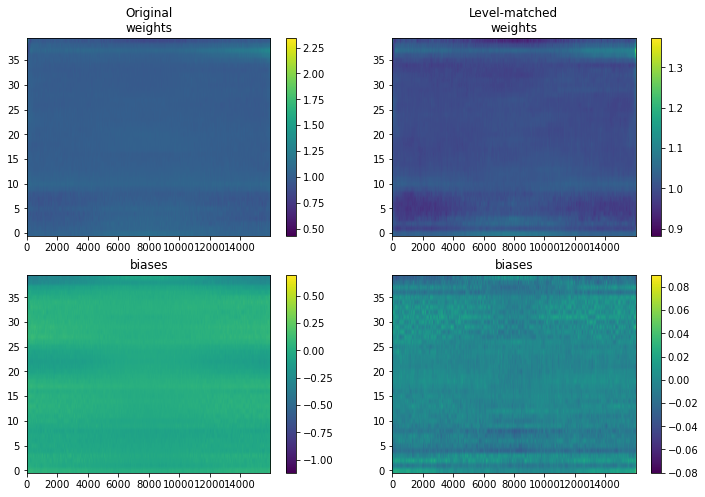

In [68]:
# plot models as columns, weights & biases are rows


plt.figure(figsize=(12,8))
plt.subplot(2,2,1)
plt.imshow(original_coch_norm_params['weight'], aspect='auto',
           filternorm=False, origin='lower',
           interpolation=None)
plt.title('Original\nweights')
plt.colorbar()

plt.subplot(2,2,2)
plt.imshow(level_matched_coch_norm_params['weight'], aspect='auto',
           filternorm=False, origin='lower',
           interpolation=None)
plt.title('Level-matched\nweights')
plt.colorbar()

plt.subplot(2,2,3)
plt.imshow(original_coch_norm_params['bias'], aspect='auto',
           filternorm=False, origin='lower',
           interpolation=None)
plt.title('biases')
plt.colorbar()

plt.subplot(2,2,4)
plt.title('biases')
plt.imshow(level_matched_coch_norm_params['bias'], aspect='auto',
           filternorm=False, origin='lower',
           interpolation=None)
plt.colorbar()


## Plot gains 


In [69]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))

In [70]:
orig_attn_params = model.attn_modules
matched_attn_params = level_matched_model.attn_modules

In [71]:
n_attn_blocks = len(orig_attn_params)

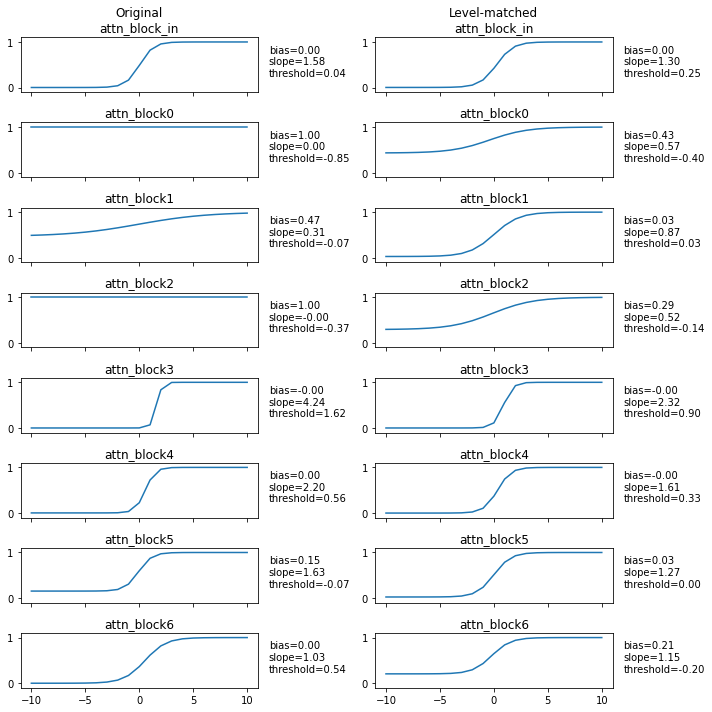

In [83]:
fig, axs = plt.subplots(n_attn_blocks, 2, sharex=True, figsize=(10,10))
axs = axs.ravel()
layer_names = [name for name in model._modules['model']._modules.keys() if 'attn' in name]
# layer_names = ['cochleagram'] + layer_names

x = np.arange(-10,11)
layer_ix = 0
for i in range((n_attn_blocks)*2):
#     print(layer_ix)
    if i % 2 == 0:
        attn_params = orig_attn_params
    else:
        attn_params = matched_attn_params
        
    bias = attn_params[layer_ix].bias.item()
    slope = attn_params[layer_ix].slope.item()
    threshold = attn_params[layer_ix].threshold.item()
    
    axs[i].plot(x, bias + (1-bias) * sigmoid((x - threshold) * slope))
    axs[i].text(12, 0.25, f"bias={bias:.2f}\nslope={slope:.2f}\nthreshold={threshold:.2f}")
    if i == 0:
        axs[i].set_title(f"Original\n{layer_names[0]}")
    elif i == 1:
        axs[i].set_title(f"Level-matched\n{layer_names[0]}")
    else:
        axs[i].set_title(layer_names[layer_ix])
    axs[i].set_ylim(-0.1,1.1)
    if i % 2 == 1:
        layer_ix += 1 
#     axs[i].set_xlim(-1,1)

    
# axs[0].set_title('')
plt.tight_layout()